# 09 结果有多可信：换切分重做一遍

02~08 的所有数字都来自**同一次切分**（随机种子 42），测试集只有 145 笔欺诈。这带来三个问题：
1. 换一次切分，分数会变多少？0.01 级别的差距算不算数？
2. 测试成绩在 02~08 里被反复查看过，虽然没用来做选择，但已经不是"从没见过"的数据；
3. 02 的缩放器是在整个训练集上拟合的，之后 05~08 才从训练集里切出验证集，验证集也参与了缩放参数。

这里从原始数据重新开始，做两件事：
- **重复切分**：同样的分组分层切分做 10 次（种子 42 和 1~9），每次都只在"拟合用"的那部分数据上拟合缩放器，模型和挑选规则与 05、06 相同。看分数的波动和模型之间的配对差。
- **按时间切分**：前 70% 时间的交易训练，后 30% 测试，模拟"用过去预测未来"。

模型：MLP、调参后的 SVM、XGBoost、并行 B（MLP + SVM，权重在验证集上选）。另外检查 08 级联第一级阈值在不同切分下是否稳定。

In [1]:
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

if os.path.exists('/content'):
    os.system('apt-get -qq install -y fonts-noto-cjk > /dev/null')
    font_path = glob.glob('/usr/share/fonts/**/NotoSansCJK*-Regular.ttc', recursive=True)[0]
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
else:
    plt.rcParams['font.family'] = ['PingFang SC', 'Heiti SC', 'Arial Unicode MS', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
import json
import time
import warnings
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.metrics import average_precision_score, precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
warnings.filterwarnings('ignore', category=ConvergenceWarning)

try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = '/content/drive/MyDrive/data-mining'
except ImportError:
    DATA_DIR = os.environ.get('CCFD_DATA_DIR', 'data')

df = pd.read_csv(f'{DATA_DIR}/creditcard.csv')
feature_cols = [c for c in df.columns if c != 'Class']
row_id = pd.util.hash_pandas_object(df, index=False).values
y_all = df['Class'].values
with open(f'{DATA_DIR}/svm_best.json') as f:
    svm_best = json.load(f)
print(f'{len(df)} 行，欺诈 {y_all.sum()} 笔；06 选出的 SVM 参数：{svm_best}')

284807 行，欺诈 492 笔；06 选出的 SVM 参数：{'C': 100.0, 'gamma': 0.0001}


## 1. 一次完整实验写成一个函数

输入"哪些行训练、哪些行测试"，函数内部：
1. 训练部分再按完整行分组切出 20% 验证集（重复行不跨边）；
2. **只用拟合部分**拟合缩放器（Amount 稳健缩放，Time 标准化），再套用到验证集和测试集；
3. 训练 MLP（30→64→32→1，20 轮）、SVM（全部欺诈 + 2 万正常）、XGBoost（验证集早停）；
4. 并行 B：验证集上做 Platt 校准，再在验证集上选 MLP 的权重；
5. 阈值按验证集 F1 最高选，测试集只用来记录结果。

`time_order=True` 时验证集不随机切，而是取训练时段里最晚的 20%。

In [3]:
def logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))

def f1_threshold(y, s):
    pr, rc, th = precision_recall_curve(y, s)
    f1 = 2 * pr[:-1] * rc[:-1] / np.clip(pr[:-1] + rc[:-1], 1e-12, None)
    return th[np.argmax(f1)]

def test_f1(y, s, t):
    pred = s >= t
    tp = (pred & (y == 1)).sum()
    return 2 * tp / max(pred.sum() + (y == 1).sum(), 1)

def run_once(train_idx, test_idx, seed, time_order=False):
    if time_order:
        order = train_idx[np.argsort(df['Time'].values[train_idx], kind='stable')]
        cut_time = df['Time'].values[order[int(len(order) * 0.8)]]
        is_fit = df['Time'].values[train_idx] < cut_time
    else:
        rid = row_id[train_idx]
        uniq = pd.DataFrame({'r': rid, 'c': y_all[train_idx]}).drop_duplicates('r')
        fit_ids, _ = train_test_split(uniq['r'], test_size=0.2, stratify=uniq['c'], random_state=seed)
        is_fit = np.isin(rid, fit_ids.values)
    fit_idx, val_idx = train_idx[is_fit], train_idx[~is_fit]

    parts = {k: df.iloc[idx][feature_cols].copy() for k, idx in
             [('fit', fit_idx), ('val', val_idx), ('test', test_idx)]}
    amount_scaler = RobustScaler().fit(parts['fit'][['Amount']])
    time_scaler = StandardScaler().fit(parts['fit'][['Time']])
    for p in parts.values():
        p['Amount'] = amount_scaler.transform(p[['Amount']])
        p['Time'] = time_scaler.transform(p[['Time']])
    X = {k: v.values for k, v in parts.items()}
    y = {'fit': y_all[fit_idx], 'val': y_all[val_idx], 'test': y_all[test_idx]}

    rng = np.random.default_rng(seed)
    svm_rows = np.concatenate([np.flatnonzero(y['fit'] == 1),
                               rng.choice(np.flatnonzero(y['fit'] == 0), 20000, replace=False)])
    mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=20, random_state=seed).fit(X['fit'], y['fit'])
    svm = SVC(kernel='rbf', C=svm_best['C'], gamma=svm_best['gamma'], class_weight='balanced',
              random_state=seed).fit(X['fit'][svm_rows], y['fit'][svm_rows])
    xgb = XGBClassifier(n_estimators=1000, max_depth=4, learning_rate=0.05, subsample=0.8,
                        colsample_bytree=0.8, eval_metric='aucpr', early_stopping_rounds=50,
                        tree_method='hist', random_state=seed, n_jobs=-1)
    xgb.fit(X['fit'], y['fit'], eval_set=[(X['val'], y['val'])], verbose=False)

    score = {'MLP': lambda A: mlp.predict_proba(A)[:, 1],
             'SVM': lambda A: svm.decision_function(A),
             'XGBoost': lambda A: xgb.predict_proba(A)[:, 1]}
    val_s = {k: f(X['val']) for k, f in score.items()}
    test_s = {k: f(X['test']) for k, f in score.items()}

    cal = {}
    for k in ['MLP', 'SVM']:
        raw_v = logit(val_s[k]) if k == 'MLP' else val_s[k]
        raw_t = logit(test_s[k]) if k == 'MLP' else test_s[k]
        m = LogisticRegression().fit(raw_v.reshape(-1, 1), y['val'])
        cal[k] = (m.predict_proba(raw_v.reshape(-1, 1))[:, 1], m.predict_proba(raw_t.reshape(-1, 1))[:, 1])
    weights = np.round(np.arange(0, 1.0001, 0.05), 2)
    val_ap = [average_precision_score(y['val'], w * cal['MLP'][0] + (1 - w) * cal['SVM'][0]) for w in weights]
    w = weights[int(np.argmax(val_ap))]
    val_s['并行 B'] = w * cal['MLP'][0] + (1 - w) * cal['SVM'][0]
    test_s['并行 B'] = w * cal['MLP'][1] + (1 - w) * cal['SVM'][1]

    row = {'种子': seed, '测试欺诈数': int(y['test'].sum()), '验证欺诈数': int(y['val'].sum()),
           '并行 B 的 MLP 权重': w, 'XGBoost 早停棵数': xgb.best_iteration + 1}
    for k in ['MLP', 'SVM', 'XGBoost', '并行 B']:
        row[f'{k} 测试 AUPRC'] = average_precision_score(y['test'], test_s[k])
        row[f'{k} 测试 F1'] = test_f1(y['test'], test_s[k], f1_threshold(y['val'], val_s[k]))

    # 08 级联第一级：按验证集召回率 R 定 MLP 阈值，看测试集有多少交易进入第二级
    fraud_scores = np.sort(val_s['MLP'][y['val'] == 1])[::-1]
    for R in [0.85, 0.90]:
        t1 = fraud_scores[int(np.ceil(R * len(fraud_scores))) - 1]
        row[f'R={R:.2f} 阈值'] = t1
        row[f'R={R:.2f} 测试进入第二级比例'] = (test_s['MLP'] >= t1).mean()
    return row

## 2. 重复切分 10 次

外层切分和 02 一样：按完整行去重后分层切 30% 作测试集。种子 42 就是 02~08 用的那次切分（区别只是缩放器改为只在拟合部分上拟合）。大约需要 5~10 分钟。

In [4]:
uniq_all = pd.DataFrame({'r': row_id, 'c': y_all}).drop_duplicates('r')
seeds = [42] + list(range(1, 10))
rows = []
start = time.time()
for seed in seeds:
    train_ids, _ = train_test_split(uniq_all['r'], test_size=0.3, stratify=uniq_all['c'], random_state=seed)
    is_train = np.isin(row_id, train_ids.values)
    rows.append(run_once(np.flatnonzero(is_train), np.flatnonzero(~is_train), seed))
    print(f'种子 {seed} 完成，累计 {time.time() - start:.0f} 秒')
rep = pd.DataFrame(rows).set_index('种子')
rep.to_csv(f'{DATA_DIR}/results_repeated_splits.csv')
models = ['MLP', 'SVM', 'XGBoost', '并行 B']
rep[[f'{m} 测试 AUPRC' for m in models] + ['测试欺诈数', '并行 B 的 MLP 权重']].round(4)

种子 42 完成，累计 21 秒


种子 1 完成，累计 43 秒


种子 2 完成，累计 62 秒


种子 3 完成，累计 81 秒


种子 4 完成，累计 101 秒


...

种子 6 完成，累计 141 秒


种子 7 完成，累计 160 秒


种子 8 完成，累计 181 秒


种子 9 完成，累计 204 秒


,MLP 测试 AUPRC,SVM 测试 AUPRC,XGBoost 测试 AUPRC,并行 B 测试 AUPRC,测试欺诈数,并行 B 的 MLP 权重
种子,,,,,,
42,0.7875,0.6775,0.8211,0.7993,145,0.85
1,0.7972,0.6969,0.7949,0.8011,143,0.90
2,0.7330,0.6907,0.7984,0.7679,146,0.75
3,0.8209,0.7055,0.8225,0.8172,152,0.45
4,0.8325,0.7742,0.8356,0.8384,153,0.90
5,0.7901,0.7115,0.8242,0.8158,144,0.60
6,0.8165,0.7637,0.8415,0.8376,150,0.75
7,0.8470,0.7902,0.8694,0.8545,146,0.80
8,0.8115,0.7481,0.8454,0.8217,146,0.65


In [5]:
summary = pd.DataFrame({
    '均值': [rep[f'{m} 测试 AUPRC'].mean() for m in models],
    '标准差': [rep[f'{m} 测试 AUPRC'].std() for m in models],
    '最低': [rep[f'{m} 测试 AUPRC'].min() for m in models],
    '最高': [rep[f'{m} 测试 AUPRC'].max() for m in models],
    'F1 均值': [rep[f'{m} 测试 F1'].mean() for m in models],
}, index=models)
summary.round(4)

,均值,标准差,最低,最高,F1 均值
MLP,0.8079,0.0335,0.7330,0.8470,0.8119
SVM,0.7353,0.0439,0.6775,0.7951,0.7588
XGBoost,0.8314,0.0243,0.7949,0.8694,0.8494
并行 B,0.8205,0.0266,0.7679,0.8545,0.8134


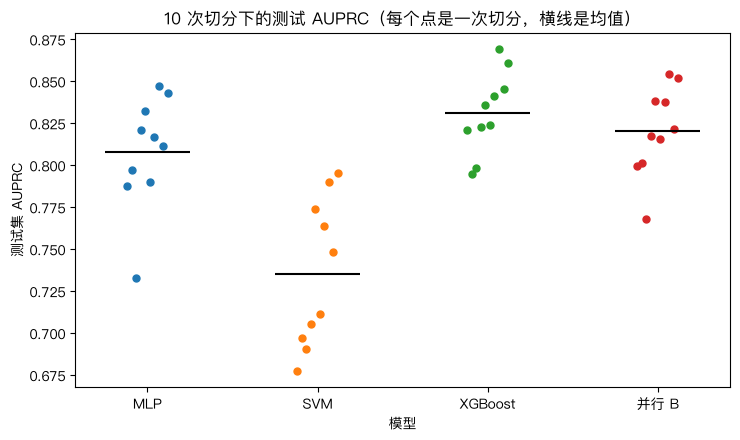

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for i, m in enumerate(models):
    v = rep[f'{m} 测试 AUPRC'].values
    ax.scatter(np.full(len(v), i) + np.linspace(-0.12, 0.12, len(v)), v, s=25)
    ax.hlines(v.mean(), i - 0.25, i + 0.25, color='black')
ax.set_xticks(range(len(models)))
ax.set_xticklabels(models)
ax.set_xlabel('模型')
ax.set_ylabel('测试集 AUPRC')
ax.set_title('10 次切分下的测试 AUPRC（每个点是一次切分，横线是均值）')
plt.tight_layout()
plt.show()

## 3. 配对差：同一次切分里，A 比 B 高多少

同一次切分下两个模型面对的是同一批测试交易，所以比较"差值"比比较各自的分数更准。

注意：10 次切分的训练集大量重叠，彼此不独立，直接用普通 t 检验会把区间算得太窄。这里用 Nadeau 和 Bengio（2003）的修正：方差乘以 (1/J + 测试集大小/训练集大小)，J 是切分次数。

这个区间的边界：SVM 参数（`svm_best.json`）和整套设计都是在同一份数据上、看过 02~08 的测试成绩之后定下的，部分新测试折里的样本也参与过当初的调参。所以它是"冻结当前配置后、换切分的敏感性区间"，不是严格的显著性检验。

In [7]:
def corrected_interval(diff, test_train_ratio=0.3 / 0.7):
    J = len(diff)
    se = np.sqrt((1 / J + test_train_ratio) * np.var(diff, ddof=1))
    half = stats.t.ppf(0.975, J - 1) * se
    return diff.mean() - half, diff.mean() + half

pairs = [('并行 B', 'MLP'), ('XGBoost', 'MLP'), ('MLP', 'SVM')]
out = []
for a, b in pairs:
    d = (rep[f'{a} 测试 AUPRC'] - rep[f'{b} 测试 AUPRC']).values
    lo, hi = corrected_interval(d)
    out.append({'比较': f'{a} − {b}', '平均差': d.mean(), 'A 更高的次数': f'{(d > 0).sum()}/{len(d)}',
                '修正后 95% 区间下限': lo, '上限': hi, '区间包含 0': lo <= 0 <= hi})
pd.DataFrame(out).set_index('比较').round(4)

,平均差,A 更高的次数,修正后 95% 区间下限,上限,区间包含 0
比较,,,,,
并行 B − MLP,0.0126,9/10,-0.0062,0.0314,True
XGBoost − MLP,0.0235,9/10,-0.0098,0.0567,True
MLP − SVM,0.0726,10/10,0.0284,0.1168,False


## 4. 08 级联第一级的阈值稳不稳

08 用"验证集召回率达到 R"来定 MLP 的阈值。验证集只有约 69 笔欺诈，R 每变 0.05 只跨过 3~4 笔，所以阈值可能跳得很厉害。下面看 10 次切分里阈值和"进入第二级的测试交易比例"。

In [8]:
rep[['验证欺诈数', 'R=0.85 阈值', 'R=0.85 测试进入第二级比例', 'R=0.90 阈值', 'R=0.90 测试进入第二级比例']].round(4)

,验证欺诈数,R=0.85 阈值,R=0.85 测试进入第二级比例,R=0.90 阈值,R=0.90 测试进入第二级比例
种子,,,,,
42,69,0.1685,0.0020,0.0001,0.0623
1,67,0.1203,0.0025,0.0106,0.0062
2,68,0.0007,0.0091,0.0000,0.0709
3,67,0.0067,0.0054,0.0002,0.0381
4,68,0.7296,0.0015,0.0053,0.0066
5,68,0.2403,0.0016,0.0004,0.0223
6,67,0.0058,0.0051,0.0000,0.0582
7,66,0.0000,0.1364,0.0000,0.2795
8,68,0.3701,0.0014,0.0178,0.0037


## 5. 按时间切分：用过去预测未来

按交易时间排序，前 70% 训练、后 30% 测试；训练部分里最晚的 20% 作验证集。完全相同的重复行时间也相同，几乎不会被切到两边。数据只有两天，这只是一次粗略检验。

In [9]:
order = np.argsort(df['Time'].values, kind='stable')
cut_time = df['Time'].values[order[int(len(order) * 0.7)]]
is_train = df['Time'].values < cut_time
time_row = run_once(np.flatnonzero(is_train), np.flatnonzero(~is_train), seed=42, time_order=True)
print(f"训练集欺诈率 {y_all[is_train].mean():.4%}，测试集欺诈率 {y_all[~is_train].mean():.4%}")
cmp = pd.DataFrame({
    '按时间切分': [time_row[f'{m} 测试 AUPRC'] for m in models],
    '随机分组切分（10 次均值）': summary['均值'].values,
}, index=models)
cmp.round(4)

训练集欺诈率 0.1926%，测试集欺诈率 0.1264%


,按时间切分,随机分组切分（10 次均值）
MLP,0.7553,0.8079
SVM,0.6941,0.7353
XGBoost,0.6736,0.8314
并行 B,0.7819,0.8205


## 看完之后记下来（用你自己的话）

1. 同一个模型换切分，测试 AUPRC 最低和最高差多少？05、06 里单次切分的 0.80、0.82 落在这个范围的什么位置？
2. 并行 B 比 MLP 高的次数是几次？修正后的区间包含 0 吗？这能不能说"融合有效"？
3. XGBoost 和 MLP 之间呢？
4. 级联第一级的阈值在不同切分下稳定吗？这说明 08 的级联结论有多可靠？
5. 按时间切分时分数掉了多少？如果真要上线，你会用哪种切分来估计效果？